In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
df = pd.read_csv('data/vk_bots_users.csv')
print('Размер датасета:', df.shape)
print()
print('Распределение целевой переменной:')
print(df['target'].value_counts())
df.head()

Размер датасета: (5874, 60)

Распределение целевой переменной:
target
1    2937
0    2937
Name: count, dtype: int64


,has_domain,has_birth_date,has_photo,can_post_on_wall,can_send_message,has_website,gender,has_short_name,has_first_name,has_last_name,...,ads_ratio,avg_views,posting_frequency_days,phone_numbers_ratio,avg_text_uniqueness,city,has_occupation,occupation_type_university,occupation_type_work,has_personal_data
0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
1,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
2,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown
4,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,Unknown,Unknown,Unknown,Unknown,Unknown


In [10]:
numeric_features = [
    'subscribers_count', 'posts_count',
    'avg_likes', 'avg_comments', 'avg_views',
    'posting_frequency_days',
    'avg_text_length', 'avg_text_uniqueness',
    'links_ratio', 'hashtags_ratio', 'ads_ratio',
    'reposts_ratio', 'attachments_ratio',
    'avg_keywords'
]

binary_features = [
    'has_photo', 'is_verified', 'is_profile_closed',
    'is_blacklisted', 'has_status', 'has_mobile',
    'has_career', 'has_universities', 'has_schools',
    'has_relatives', 'has_interests', 'has_books'
]

selected = numeric_features + binary_features + ['target']
df_selected = df[selected].copy()

for col in numeric_features + binary_features + ['target']:
    df_selected[col] = pd.to_numeric(df_selected[col], errors='coerce')

df_selected = df_selected.dropna()

print('Размер после очистки:', df_selected.shape)
print()
print('Типы данных:')
print(df_selected.dtypes)
print()
print('Распределение target:')
print(df_selected['target'].value_counts())

Размер после очистки: (645, 27)

Типы данных:
subscribers_count         float64
posts_count               float64
avg_likes                 float64
avg_comments              float64
avg_views                 float64
posting_frequency_days    float64
avg_text_length           float64
avg_text_uniqueness       float64
links_ratio               float64
hashtags_ratio            float64
ads_ratio                 float64
reposts_ratio             float64
attachments_ratio         float64
avg_keywords              float64
has_photo                 float64
is_verified               float64
is_profile_closed         float64
is_blacklisted            float64
has_status                float64
has_mobile                float64
has_career                float64
has_universities          float64
has_schools               float64
has_relatives             float64
has_interests             float64
has_books                 float64
target                      int64
dtype: object

Распределение target:

In [11]:
df_selected = df_selected.dropna()
print('После удаления пропусков:', df_selected.shape)
print('Распределение target:')
print(df_selected['target'].value_counts())

После удаления пропусков: (645, 27)
Распределение target:
target
0    589
1     56
Name: count, dtype: int64


In [12]:
print('Статистика по числовым признакам:')
df_selected[numeric_features].describe().round(2)

Статистика по числовым признакам:


,subscribers_count,posts_count,avg_likes,avg_comments,avg_views,posting_frequency_days,avg_text_length,avg_text_uniqueness,links_ratio,hashtags_ratio,ads_ratio,reposts_ratio,attachments_ratio,avg_keywords
count,645.00,645.00,645.00,645.00,645.00,645.00,645.00,645.00,645.00,645.00,645.00,645.00,645.00,645.00
mean,2771.50,18.25,24.37,1.07,841.29,67.07,369.15,0.68,0.14,0.13,0.00,0.32,0.90,4.99
std,5470.94,4.76,56.11,3.44,2172.22,127.15,507.17,0.24,0.19,0.20,0.05,0.35,0.17,6.84
min,5.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,336.00,20.00,2.10,0.00,118.00,8.88,76.80,0.58,0.00,0.00,0.00,0.00,0.90,1.00
50%,1082.00,20.00,9.95,0.05,403.35,35.48,209.55,0.74,0.05,0.05,0.00,0.15,1.00,2.70
75%,3326.00,20.00,30.85,0.90,950.75,90.79,458.55,0.86,0.20,0.15,0.00,0.60,1.00,6.25
max,103729.00,20.00,894.90,64.05,41415.70,2165.64,5841.25,1.00,1.00,1.00,0.95,1.00,1.00,61.60


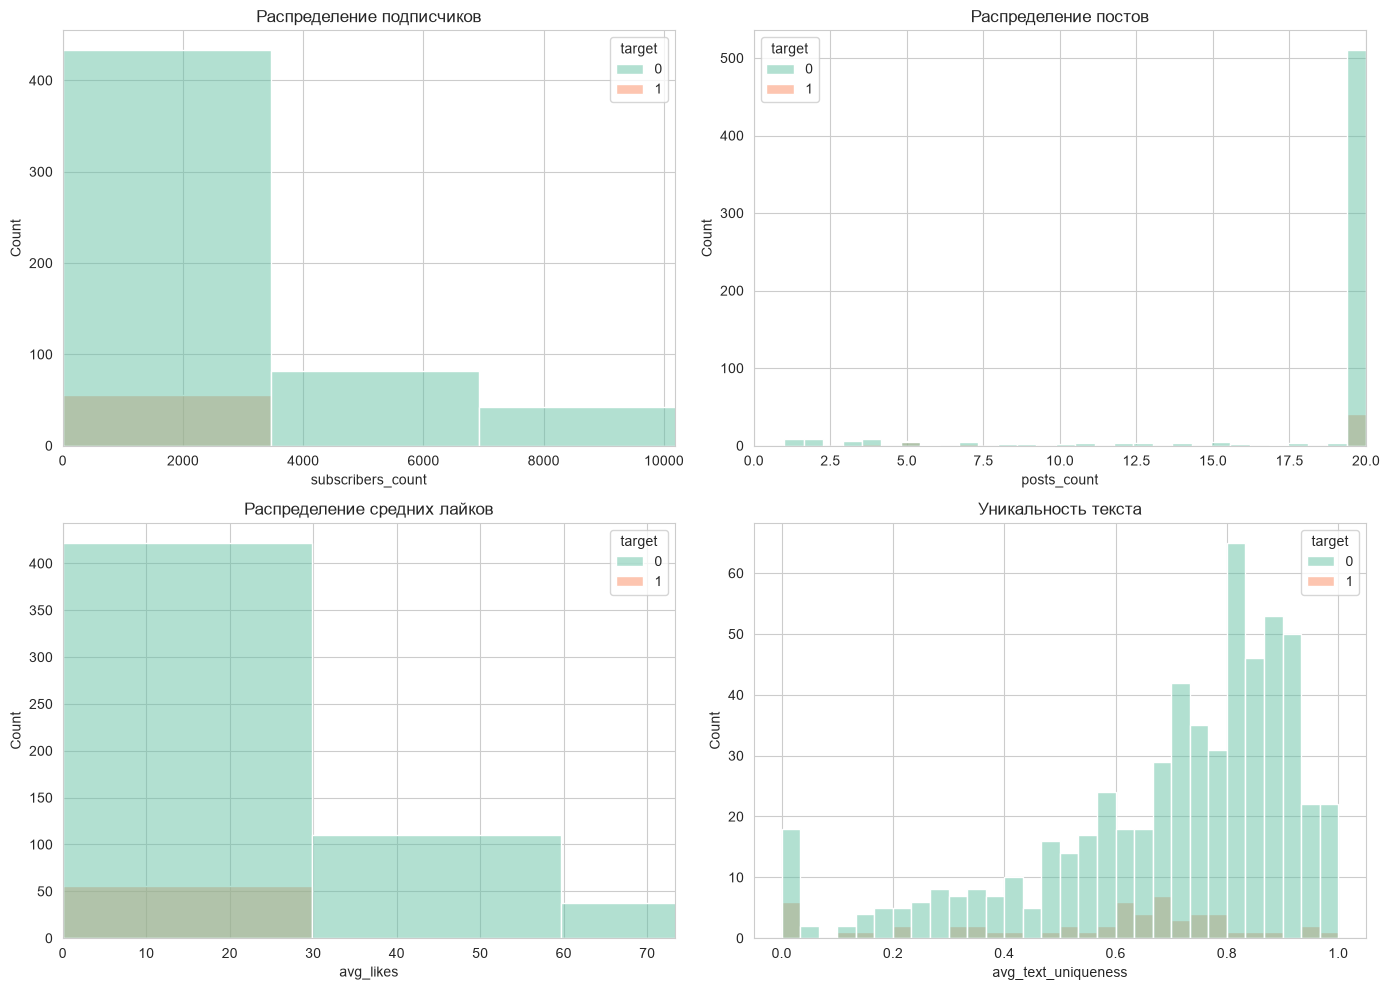

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=df_selected, x='subscribers_count', hue='target', bins=30, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Распределение подписчиков')
axes[0, 0].set_xlim(0, df_selected['subscribers_count'].quantile(0.95))

sns.histplot(data=df_selected, x='posts_count', hue='target', bins=30, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Распределение постов')
axes[0, 1].set_xlim(0, df_selected['posts_count'].quantile(0.95))

sns.histplot(data=df_selected, x='avg_likes', hue='target', bins=30, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Распределение средних лайков')
axes[1, 0].set_xlim(0, df_selected['avg_likes'].quantile(0.95))

sns.histplot(data=df_selected, x='avg_text_uniqueness', hue='target', bins=30, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Уникальность текста')

plt.tight_layout()
plt.savefig('docs/vk_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

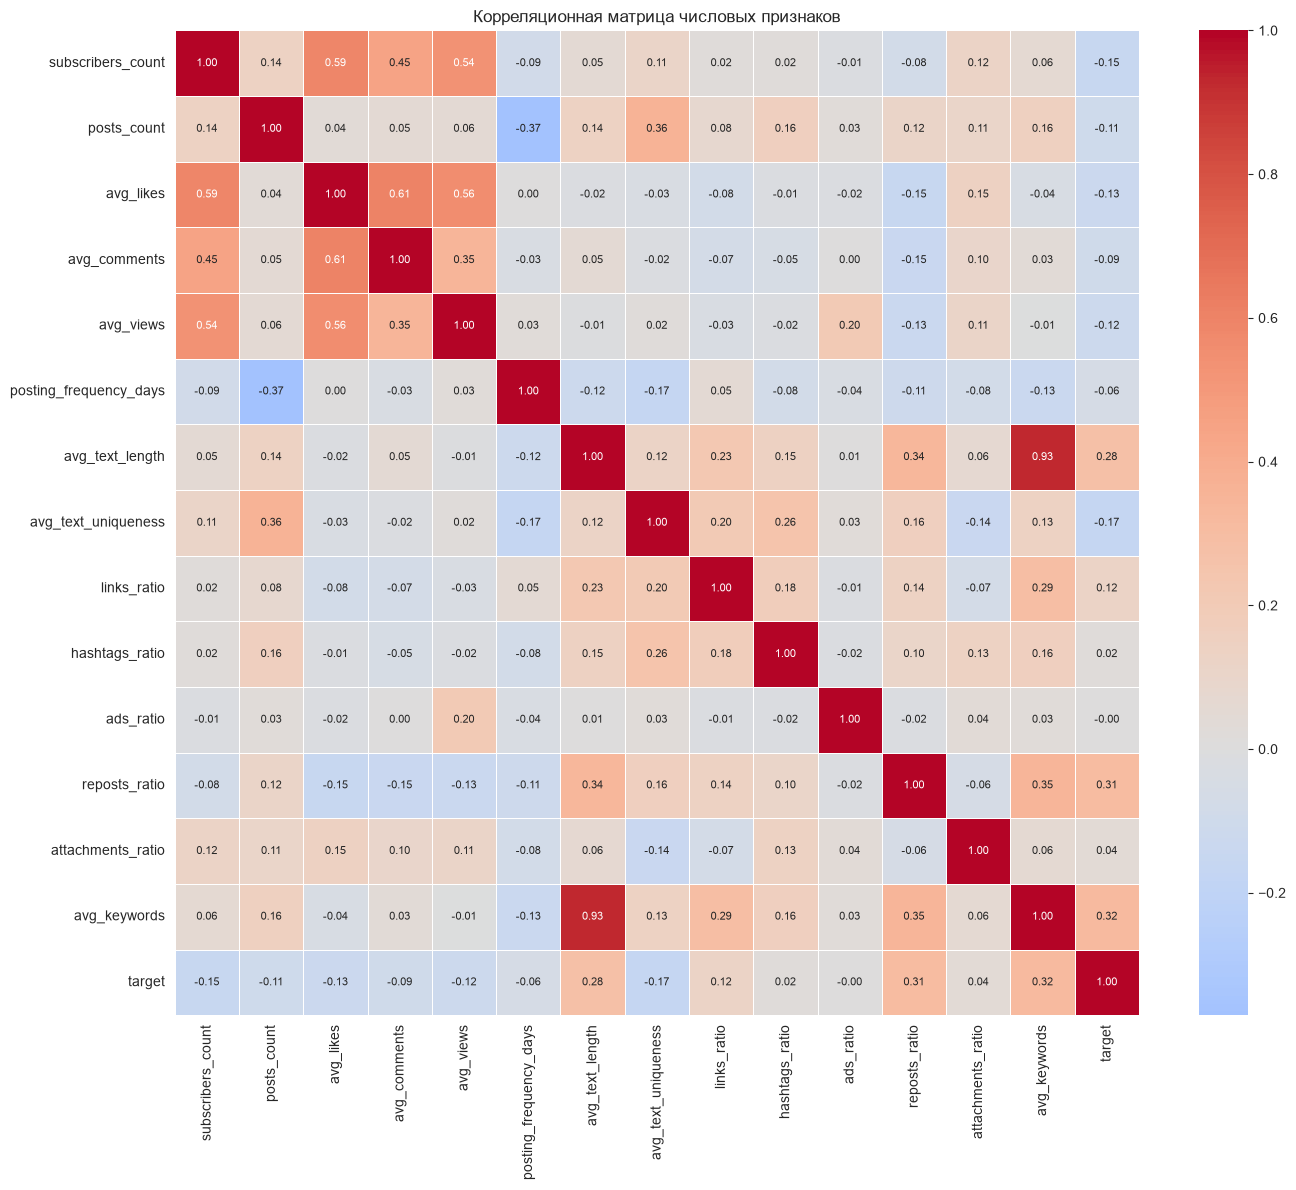

In [14]:
correlation_matrix = df_selected[numeric_features + ['target']].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.savefig('docs/vk_correlation.png', dpi=200, bbox_inches='tight')
plt.show()

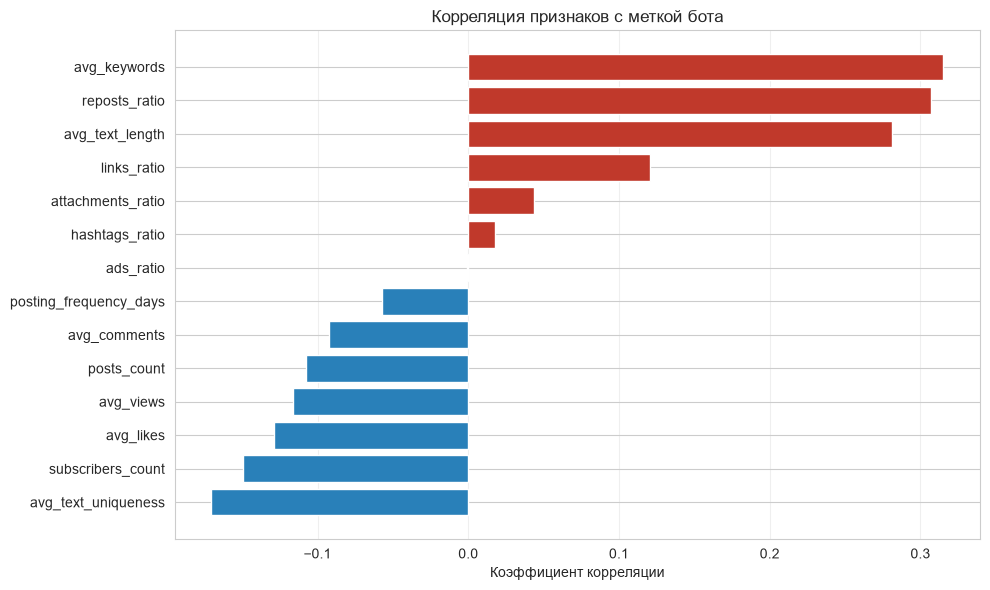

Значения корреляции:
avg_text_uniqueness      -0.170
subscribers_count        -0.149
avg_likes                -0.129
avg_views                -0.116
posts_count              -0.108
avg_comments             -0.092
posting_frequency_days   -0.057
ads_ratio                -0.001
hashtags_ratio            0.018
attachments_ratio         0.044
links_ratio               0.121
avg_text_length           0.281
reposts_ratio             0.307
avg_keywords              0.315
dtype: float64


In [15]:
target_corr = df_selected[numeric_features].corrwith(df_selected['target']).sort_values()

plt.figure(figsize=(10, 6))
colors = ['#c0392b' if x > 0 else '#2980b9' for x in target_corr]
plt.barh(target_corr.index, target_corr.values, color=colors)
plt.title('Корреляция признаков с меткой бота')
plt.xlabel('Коэффициент корреляции')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('docs/vk_target_correlation.png', dpi=200, bbox_inches='tight')
plt.show()

print('Значения корреляции:')
print(target_corr.round(3))

In [16]:
X = df_selected[numeric_features + binary_features]
y = df_selected['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Обучающая выборка:', X_train.shape)
print('Тестовая выборка:', X_test.shape)

Обучающая выборка: (483, 26)
Тестовая выборка: (162, 26)


In [18]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print('Логистическая регрессия')
print('Accuracy:', (y_pred_lr == y_test).mean().round(4))
print('ROC AUC:', round(roc_auc_score(y_test, y_proba_lr), 4))
print()
print(classification_report(y_test, y_pred_lr, target_names=['Реальный', 'Бот']))

Логистическая регрессия
Accuracy: 0.9506
ROC AUC: 0.9392

              precision    recall  f1-score   support

    Реальный       0.96      0.99      0.97       148
         Бот       0.80      0.57      0.67        14

    accuracy                           0.95       162
   macro avg       0.88      0.78      0.82       162
weighted avg       0.95      0.95      0.95       162



In [20]:
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('Случайный лес')
print('Accuracy:', (y_pred_rf == y_test).mean().round(4))
print('ROC AUC:', round(roc_auc_score(y_test, y_proba_lr), 4))
print()
print(classification_report(y_test, y_pred_rf, target_names=['Реальный', 'Бот']))

Случайный лес
Accuracy: 0.9691
ROC AUC: 0.9392

              precision    recall  f1-score   support

    Реальный       0.97      1.00      0.98       148
         Бот       1.00      0.64      0.78        14

    accuracy                           0.97       162
   macro avg       0.98      0.82      0.88       162
weighted avg       0.97      0.97      0.97       162



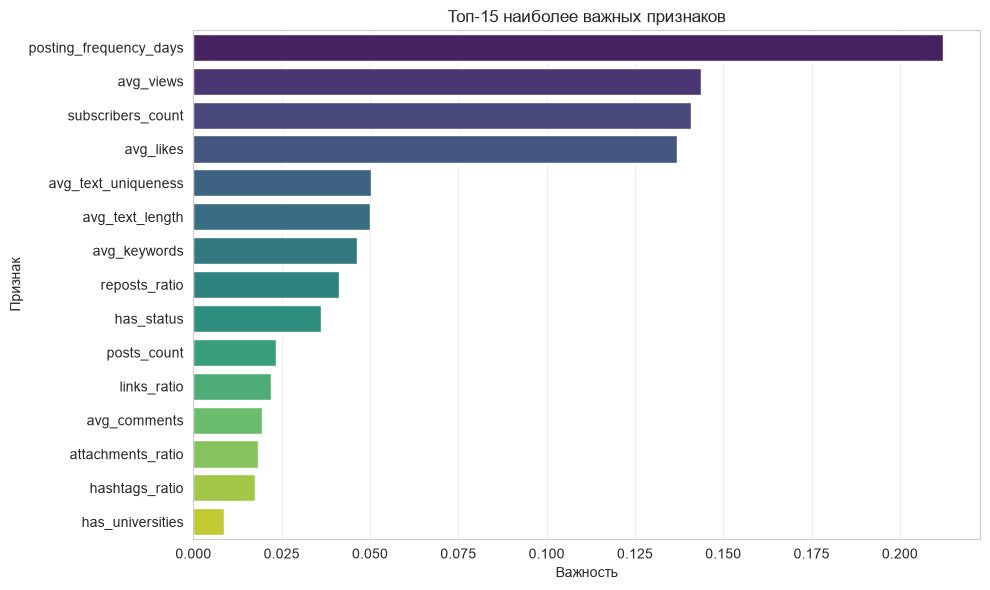

Важность признаков:
posting_frequency_days    0.2121
avg_views                 0.1436
subscribers_count         0.1409
avg_likes                 0.1370
avg_text_uniqueness       0.0503
avg_text_length           0.0499
avg_keywords              0.0464
reposts_ratio             0.0411
has_status                0.0361
posts_count               0.0235
links_ratio               0.0219
avg_comments              0.0194
attachments_ratio         0.0182
hashtags_ratio            0.0174
has_universities          0.0086
dtype: float64


In [22]:
importances = pd.Series(rf.feature_importances_, index=numeric_features + binary_features)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title('Топ-15 наиболее важных признаков')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('docs/vk_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

print('Важность признаков:')
print(importances.round(4))

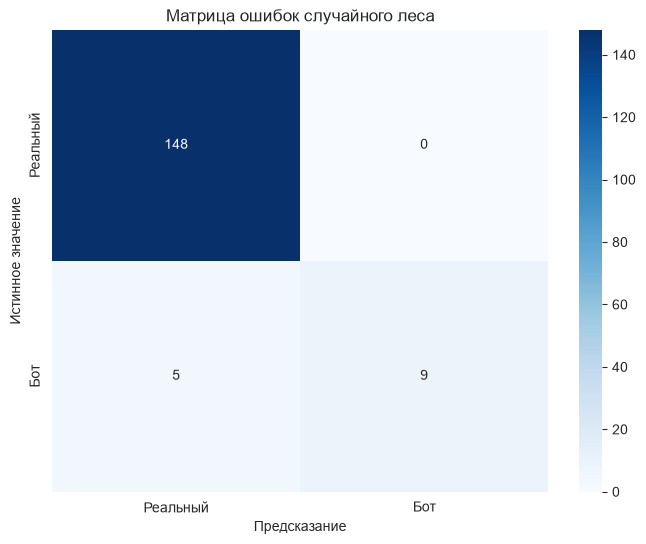

In [23]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Реальный', 'Бот'],
            yticklabels=['Реальный', 'Бот'])
plt.title('Матрица ошибок случайного леса')
plt.xlabel('Предсказание')
plt.ylabel('Истинное значение')
plt.savefig('docs/vk_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

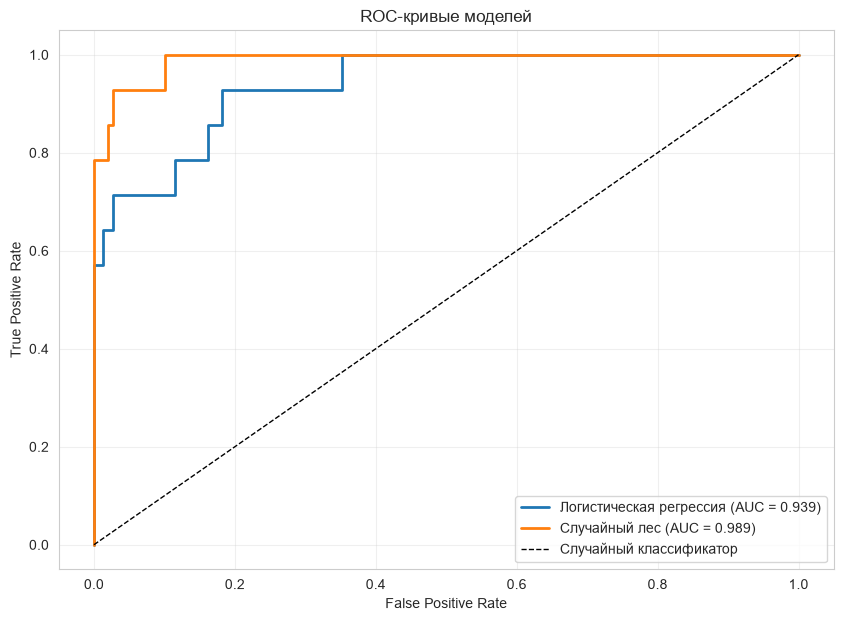

In [24]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Логистическая регрессия (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Случайный лес (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('docs/vk_roc_curves.png', dpi=200, bbox_inches='tight')
plt.show()

In [25]:
print('Итоги анализа:')
print(f'Всего профилей: {len(df_selected)}')
print(f'Ботов: {(df_selected["target"] == 1).sum()} ({(df_selected["target"] == 1).mean() * 100:.1f}%)')
print(f'Реальных: {(df_selected["target"] == 0).sum()} ({(df_selected["target"] == 0).mean() * 100:.1f}%)')
print()
print('Лучшие модели по ROC AUC:')
print(f'Логистическая регрессия: {roc_auc_score(y_test, y_proba_lr):.4f}')
print(f'Случайный лес: {roc_auc_score(y_test, y_proba_rf):.4f}')
print()
print('Три наиболее важных признака для детекции ботов:')
print(importances.head(3).round(4))

Итоги анализа:
Всего профилей: 645
Ботов: 56 (8.7%)
Реальных: 589 (91.3%)

Лучшие модели по ROC AUC:
Логистическая регрессия: 0.9392
Случайный лес: 0.9894

Три наиболее важных признака для детекции ботов:
posting_frequency_days    0.2121
avg_views                 0.1436
subscribers_count         0.1409
dtype: float64
